# Direct 6-model ensemble weight optimization


In [1]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.8 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompa

## 1. Setup: imports, constants and paths

In [ ]:
from pathlib import Path
import copy
import time
import random
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import efficientnet_b7, efficientnet_b0

from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,
    Resize,
    NormalizeIntensity,
    Lambda,
    ToTensor
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

CLASS_NAMES = ["Biliary_Leaks", "Lithiasis", "Normal", "Stricture"]
NUM_CLASSES = len(CLASS_NAMES)

POSITIVE_CLASS = "Biliary_Leaks"
POSITIVE_IDX = CLASS_NAMES.index(POSITIVE_CLASS)

REAL_DATASET_ROOT = Path("/kaggle/input/datasets/martimflix/dataset_monica/dataset_monica")
GENERATED_ROOT = Path("/kaggle/input/datasets/martimflix/vae-generated/vae_generated_perceptual")

REAL_TRAIN_DIR = REAL_DATASET_ROOT / "train"
VAL_DIR = REAL_DATASET_ROOT / "val"
TEST_DIR = REAL_DATASET_ROOT / "test"

EFFICIENTNET_CKPT_PATH = Path(
    "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-31 13:56:01.578704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780235761.815399      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780235761.887232      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780235762.465691      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780235762.465731      58 computation_placer.cc:1

Device: cuda


## 2. Dataset verification

In [3]:
def count_images(folder):
    exts = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]
    files = []

    if not folder.exists():
        return 0

    for ext in exts:
        files.extend(folder.glob(ext))

    return len(files)


rows = []

for cls in CLASS_NAMES:
    rows.append({
        "Class": cls,
        "Real train": count_images(REAL_TRAIN_DIR / cls),
        "Generated": count_images(GENERATED_ROOT / cls),
        "Val real": count_images(VAL_DIR / cls),
        "Test real": count_images(TEST_DIR / cls)
    })

counts_df = pd.DataFrame(rows)
counts_df

,Class,Real train,Generated,Val real,Test real
0,Biliary_Leaks,110,300,24,17
1,Lithiasis,505,0,98,123
2,Normal,197,300,59,43
3,Stricture,255,300,53,84


## 3. Image transforms

In [4]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img


train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

eval_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

print("Transforms ready.")

Transforms ready.


## 4. Evaluation data loaders

In [5]:
USE_GENERATED_BILIARY = True


def collect_binary_paths(root_dir):
    image_files = []
    labels = []

    for cls in CLASS_NAMES:
        cls_dir = root_dir / cls

        cls_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            cls_files.extend(cls_dir.glob(ext))

        cls_files = sorted(cls_files)

        binary_label = 1 if cls == POSITIVE_CLASS else 0

        image_files.extend(cls_files)
        labels.extend([binary_label] * len(cls_files))

    return image_files, labels


def collect_binary_train_paths(real_train_dir, generated_root, use_generated_biliary=False):
    image_files, labels = collect_binary_paths(real_train_dir)

    if use_generated_biliary:
        gen_dir = generated_root / POSITIVE_CLASS

        generated_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            generated_files.extend(gen_dir.glob(ext))

        generated_files = sorted(generated_files)

        image_files.extend(generated_files)
        labels.extend([1] * len(generated_files))

    return image_files, labels


class BinaryPathDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = list(image_files)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = self.transform(str(self.image_files[idx]))
        label = torch.tensor(float(self.labels[idx]), dtype=torch.float32)
        return img, label


binary_train_files, binary_train_labels = collect_binary_train_paths(
    real_train_dir=REAL_TRAIN_DIR,
    generated_root=GENERATED_ROOT,
    use_generated_biliary=USE_GENERATED_BILIARY
)

binary_val_files, binary_val_labels = collect_binary_paths(VAL_DIR)
binary_test_files, binary_test_labels = collect_binary_paths(TEST_DIR)

binary_train_ds = BinaryPathDataset(
    binary_train_files,
    binary_train_labels,
    train_transforms
)

binary_val_ds = BinaryPathDataset(
    binary_val_files,
    binary_val_labels,
    eval_transforms
)

binary_test_ds = BinaryPathDataset(
    binary_test_files,
    binary_test_labels,
    eval_transforms
)

binary_counts_df = pd.DataFrame([
    {
        "Split": "Train",
        "Biliary_Leaks": int(sum(binary_train_labels)),
        "Rest": int(len(binary_train_labels) - sum(binary_train_labels)),
        "Total": len(binary_train_labels)
    },
    {
        "Split": "Validation",
        "Biliary_Leaks": int(sum(binary_val_labels)),
        "Rest": int(len(binary_val_labels) - sum(binary_val_labels)),
        "Total": len(binary_val_labels)
    },
    {
        "Split": "Test",
        "Biliary_Leaks": int(sum(binary_test_labels)),
        "Rest": int(len(binary_test_labels) - sum(binary_test_labels)),
        "Total": len(binary_test_labels)
    }
])

binary_counts_df

,Split,Biliary_Leaks,Rest,Total
0,Train,410,957,1367
1,Validation,24,210,234
2,Test,17,250,267


In [6]:
BATCH_SIZE = 8

binary_train_loader = DataLoader(
    binary_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

binary_val_loader = DataLoader(
    binary_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

binary_test_loader = DataLoader(
    binary_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print("Binary loaders ready.")
print("Train batches:", len(binary_train_loader))
print("Val batches:", len(binary_val_loader))
print("Test batches:", len(binary_test_loader))

Binary loaders ready.
Train batches: 171
Val batches: 30
Test batches: 34


## 5. Checkpoint loading utilities

In [7]:
def clean_state_dict_keys(state_dict):
    cleaned = {}

    for k, v in state_dict.items():
        new_k = k

        if new_k.startswith("module."):
            new_k = new_k[len("module."):]

        cleaned[new_k] = v

    return cleaned


def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu"
        )


def load_checkpoint_safely(model, checkpoint_path):
    checkpoint = safe_torch_load(checkpoint_path)

    if isinstance(checkpoint, dict):
        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        elif "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    state_dict = clean_state_dict_keys(state_dict)

    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    print("Checkpoint loaded.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    return model

## 6. Multiclass helpers and labels

In [8]:

from torchvision.models import mobilenet_v2, resnet50
from monai.networks.nets import DenseNet121 as MonaiDenseNet121


def collect_multiclass_paths(root_dir):
    image_files = []
    labels = []

    for class_idx, cls in enumerate(CLASS_NAMES):
        cls_dir = root_dir / cls
        cls_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            cls_files.extend(cls_dir.glob(ext))
        cls_files = sorted(cls_files)
        image_files.extend(cls_files)
        labels.extend([class_idx] * len(cls_files))

    return image_files, np.asarray(labels, dtype=int)


_, y_val_multiclass = collect_multiclass_paths(VAL_DIR)
_, y_test_multiclass = collect_multiclass_paths(TEST_DIR)

print("Validation labels:", y_val_multiclass.shape)
print("Test labels:", y_test_multiclass.shape)


@torch.no_grad()
def predict_multiclass_probs(model, loader):
    model.eval()
    all_probs = []

    for images, _ in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.detach().cpu().numpy())

    return np.concatenate(all_probs, axis=0)


def evaluate_multiclass_predictions(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"================ {title} ================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("Confusion matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "cm": cm,
    }


def extract_class_metrics(y_true, y_pred, class_idx):
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    class_name = CLASS_NAMES[class_idx]
    return {
        "Precision": report[class_name]["precision"],
        "Recall": report[class_name]["recall"],
        "F1": report[class_name]["f1-score"],
    }


Validation labels: (234,)
Test labels: (267,)


## 7. Four-model ensemble components

In [9]:

def first_valid_path(paths, model_name):
    for p in paths:
        p = Path(p)
        if p.exists() and p.stat().st_size > 1_000_000:
            with open(p, "rb") as f:
                first_bytes = f.read(80)
            if not first_bytes.startswith(b"version https://git-lfs.github.com"):
                print(f"{model_name}: {p}")
                return p
    raise FileNotFoundError(f"No valid checkpoint found for {model_name}")


SANDRA_MODELS = {
    "efficientnet": first_valid_path([
        "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth",
        "/kaggle/input/models/martimflix/efficientnet-original/pytorch/default/1/efficientnet_b7_original.pth",
    ], "EfficientNet-B7"),

    "sandra_densenet": first_valid_path([
        "/kaggle/input/models/martimflix/densenet-sandra/pytorch/default/1/densenet_imagens_geradas_todas_410.pth",
        "/kaggle/input/models/martimflix/densenet-sandra-generated/pytorch/default/1/densenet_sandra.pth",
    ], "Sandra DenseNet"),

    "mobilenet": first_valid_path([
        "/kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth",
        "/kaggle/input/models/martimflix/mobilenetv2/pytorch/default/1/mobilenet_v2.pth",
        "/kaggle/input/models/martimflix/mobilenet-original/pytorch/default/1/mobilenet_v2_original.pth",
    ], "MobileNetV2 original"),

    "resnet": first_valid_path([
        "/kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50_img_geradas_410.pth",
        "/kaggle/input/models/martimflix/resnet-sandra/pytorch/default/1/resnet50_sandra.pth",
        "/kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50.pth",
    ], "ResNet50"),
}

# Safety check: validated checkpoints
RUNNING_ON_KAGGLE = Path("/kaggle/input").exists()

if RUNNING_ON_KAGGLE:
    expected_paths = {
        "efficientnet": "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth",
        "sandra_densenet": "/kaggle/input/models/martimflix/densenet-sandra/pytorch/default/1/densenet_imagens_geradas_todas_410.pth",
        "mobilenet": "/kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth",
        "resnet": "/kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50_img_geradas_410.pth",
    }

    for model_name, expected_path in expected_paths.items():
        actual_path = str(SANDRA_MODELS[model_name])

        assert actual_path == expected_path, (
            f"Wrong checkpoint selected for {model_name}.\n"
            f"Expected: {expected_path}\n"
            f"Got:      {actual_path}\n"
            "This may change the final reproduced result."
        )

    print("Kaggle checkpoint validation passed: exact validated checkpoints are being used.")

else:
    print("Local execution detected: skipping absolute Kaggle path validation.")

    for model_name, path in SANDRA_MODELS.items():
        path = Path(path)

        assert path.exists(), f"Checkpoint not found for {model_name}: {path}"
        assert path.stat().st_size > 1_000_000, (
            f"Checkpoint for {model_name} is too small and may be invalid: {path}"
        )

        with open(path, "rb") as f:
            first_bytes = f.read(80)

        assert not first_bytes.startswith(b"version https://git-lfs.github.com"), (
            f"Checkpoint for {model_name} is a Git LFS pointer, not a real model: {path}"
        )

    print("Local checkpoint validation passed: selected files look like valid .pth checkpoints.")


pd.DataFrame([
    {
        "model": name,
        "path": str(path),
        "size_mb": path.stat().st_size / (1024 ** 2),
    }
    for name, path in SANDRA_MODELS.items()
])


def create_ensemble_model(arch):
    if arch == "efficientnet":
        model = efficientnet_b7(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES,
        )

    elif arch == "sandra_densenet":
        model = MonaiDenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=NUM_CLASSES,
        )

    elif arch == "mobilenet":
        model = mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES,
        )

    elif arch == "resnet":
        model = resnet50(weights=None)
        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES,
        )

    else:
        raise ValueError(f"Unknown architecture: {arch}")

    model = load_checkpoint_safely(model, SANDRA_MODELS[arch])
    model = model.to(device)
    model.eval()
    return model


sandra_individual_val_probs = {}
sandra_individual_test_probs = {}
individual_rows = []

for arch in SANDRA_MODELS:
    print("=" * 100)
    print(f"Loading {arch}...")

    model_tmp = create_ensemble_model(arch)

    val_probs = predict_multiclass_probs(model_tmp, binary_val_loader)
    test_probs = predict_multiclass_probs(model_tmp, binary_test_loader)

    sandra_individual_val_probs[arch] = val_probs
    sandra_individual_test_probs[arch] = test_probs

    val_preds = np.argmax(val_probs, axis=1)
    test_preds = np.argmax(test_probs, axis=1)

    individual_rows.append({
        "Model": arch,
        "Val Macro-F1": f1_score(y_val_multiclass, val_preds, average="macro"),
        "Test Macro-F1": f1_score(y_test_multiclass, test_preds, average="macro"),
    })

    del model_tmp
    if device.type == "cuda":
        torch.cuda.empty_cache()

individual_model_results = pd.DataFrame(individual_rows).sort_values(
    by="Val Macro-F1",
    ascending=False,
).reset_index(drop=True)

individual_model_results.round(4)


EfficientNet-B7: /kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth
Sandra DenseNet: /kaggle/input/models/martimflix/densenet-sandra/pytorch/default/1/densenet_imagens_geradas_todas_410.pth
MobileNetV2 original: /kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth
ResNet50: /kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50_img_geradas_410.pth
Kaggle checkpoint validation passed: exact validated checkpoints are being used.
Loading efficientnet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading sandra_densenet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading mobilenet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading resnet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0


,Model,Val Macro-F1,Test Macro-F1
0,efficientnet,0.6008,0.7439
1,mobilenet,0.5893,0.5578
2,sandra_densenet,0.5825,0.6665
3,resnet,0.5688,0.7359


## 8. EfficientNet-B0 VAE component

In [10]:
# EfficientNet-B0 VAE model loading and evaluation

from monai.transforms import Compose, LoadImage, EnsureChannelFirst, Resize, NormalizeIntensity, Lambda, ToTensor

EFFICIENTNET_B0_CKPT_PATH = Path(
    "/kaggle/input/models/martimflix/efficient-netb0/pytorch/default/1/efficientnet_b0_VAE_resized.pth"
)

assert EFFICIENTNET_B0_CKPT_PATH.exists(), f"EfficientNet-B0 checkpoint not found: {EFFICIENTNET_B0_CKPT_PATH}"
assert EFFICIENTNET_B0_CKPT_PATH.stat().st_size > 1_000_000, "EfficientNet-B0 checkpoint seems invalid."

print("EfficientNet-B0 checkpoint:")
print(EFFICIENTNET_B0_CKPT_PATH)
print("Size MB:", EFFICIENTNET_B0_CKPT_PATH.stat().st_size / (1024 ** 2))


# EfficientNet-B0 notebook used 224x224 images.
b0_eval_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])


class MulticlassPathDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = list(image_files)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = self.transform(str(self.image_files[idx]))
        label = int(self.labels[idx])
        return img, label


val_files_multiclass, y_val_check = collect_multiclass_paths(VAL_DIR)
test_files_multiclass, y_test_check = collect_multiclass_paths(TEST_DIR)

assert np.array_equal(y_val_check, y_val_multiclass), "Validation label order mismatch."
assert np.array_equal(y_test_check, y_test_multiclass), "Test label order mismatch."


b0_val_ds = MulticlassPathDataset(
    val_files_multiclass,
    y_val_multiclass,
    b0_eval_transforms
)

b0_test_ds = MulticlassPathDataset(
    test_files_multiclass,
    y_test_multiclass,
    b0_eval_transforms
)

b0_val_loader = DataLoader(
    b0_val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

b0_test_loader = DataLoader(
    b0_test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)


def create_efficientnet_b0_vae_model():
    model = efficientnet_b0(weights=None)

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    )

    model = load_checkpoint_safely(model, EFFICIENTNET_B0_CKPT_PATH)
    model = model.to(device)
    model.eval()
    return model


efficientnet_b0_model = create_efficientnet_b0_vae_model()

b0_val_probs = predict_multiclass_probs(efficientnet_b0_model, b0_val_loader)
b0_test_probs = predict_multiclass_probs(efficientnet_b0_model, b0_test_loader)

b0_val_preds = np.argmax(b0_val_probs, axis=1)
b0_test_preds = np.argmax(b0_test_probs, axis=1)

b0_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    b0_val_preds,
    title="EfficientNet-B0 VAE - Validation"
)

b0_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    b0_test_preds,
    title="EfficientNet-B0 VAE - Test"
)

del efficientnet_b0_model
if device.type == "cuda":
    torch.cuda.empty_cache()

EfficientNet-B0 checkpoint:
/kaggle/input/models/martimflix/efficient-netb0/pytorch/default/1/efficientnet_b0_VAE_resized.pth
Size MB: 15.598944664001465
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
================ EfficientNet-B0 VAE - Validation ================
Accuracy: 0.5726
Macro-F1: 0.5085
               precision    recall  f1-score   support

Biliary_Leaks     0.3846    0.2083    0.2703        24
    Lithiasis     0.7381    0.6327    0.6813        98
       Normal     0.6038    0.5424    0.5714        59
    Stricture     0.4167    0.6604    0.5109        53

     accuracy                         0.5726       234
    macro avg     0.5358    0.5109    0.5085       234
 weighted avg     0.5952    0.5726    0.5729       234

Confusion matrix:
[[ 5  5 10  4]
 [ 2 62  8 26]
 [ 1  7 32 19]
 [ 5 10  3 35]]
================ EfficientNet-B0 VAE - Test ================
Accuracy: 0.6966
Macro-F1: 0.6492
               precision    recall  f1-score   support

Biliary_Leaks     

## 9. ConvNeXt-Tiny VAE component

In [11]:
# ConvNeXt-Tiny VAE 

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import seaborn as sns
import torch.nn.functional as F
from IPython.display import FileLink, display
import shutil
import json


def find_convnext_checkpoint():
    """
    Finds the ConvNeXt-Tiny VAE checkpoint attached as a Kaggle input/model.
    The known filename is convnext_tiny_VAE_seed0.pth.
    """
    candidate_paths = [
        "/kaggle/input/models/martimflix/convenet-sandra/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/models/martimflix/convnet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/models/martimflix/convNet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/convenet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/convnet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/convNet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
    ]

    for p in candidate_paths:
        p = Path(p)
        if p.exists() and p.stat().st_size > 1_000_000:
            with open(p, "rb") as f:
                first_bytes = f.read(80)
            if not first_bytes.startswith(b"version https://git-lfs.github.com"):
                print("ConvNeXt checkpoint found:")
                print(p)
                print("Size MB:", p.stat().st_size / (1024 ** 2))
                return p

    print("Searching for ConvNeXt checkpoint inside /kaggle/input ...")
    matches = []
    for p in Path("/kaggle/input").rglob("*.pth"):
        name = p.name.lower()
        path_str = str(p).lower()
        if (
            ("convnext" in name or "convnext" in path_str or "convenet" in path_str or "convnet" in path_str)
            and p.stat().st_size > 1_000_000
        ):
            with open(p, "rb") as f:
                first_bytes = f.read(80)
            if not first_bytes.startswith(b"version https://git-lfs.github.com"):
                matches.append(p)

    if len(matches) == 0:
        print("All .pth files under /kaggle/input:")
        for p in Path("/kaggle/input").rglob("*.pth"):
            print("-", p, "| size MB:", p.stat().st_size / (1024 ** 2))
        raise FileNotFoundError("Could not find convnext_tiny_VAE_seed0.pth. Attach the Kaggle model/input first.")

    print("Possible ConvNeXt checkpoints found:")
    for p in matches:
        print("-", p, "| size MB:", p.stat().st_size / (1024 ** 2))

    return matches[0]


CONVNEXT_CKPT_PATH = find_convnext_checkpoint()


def create_convnext_tiny_vae_model(strict=True):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, NUM_CLASSES),
    )

    state_dict = torch.load(CONVNEXT_CKPT_PATH, map_location=device)
    model.load_state_dict(state_dict, strict=strict)

    model = model.to(device)
    model.eval()
    return model


convnext_model = create_convnext_tiny_vae_model(strict=True)
print("ConvNeXt-Tiny VAE loaded with strict=True.")


ConvNeXt checkpoint found:
/kaggle/input/models/martimflix/convenet-sandra/pytorch/default/1/convnext_tiny_VAE_seed0.pth
Size MB: 106.20369243621826
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 176MB/s] 


ConvNeXt-Tiny VAE loaded with strict=True.


In [12]:
# ConvNeXt probabilities

convnext_val_probs = predict_multiclass_probs(convnext_model, binary_val_loader)
convnext_test_probs = predict_multiclass_probs(convnext_model, binary_test_loader)

convnext_val_preds = np.argmax(convnext_val_probs, axis=1)
convnext_test_preds = np.argmax(convnext_test_probs, axis=1)

convnext_individual_results = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny VAE alone",
        "Split": "validation",
        "Accuracy": accuracy_score(y_val_multiclass, convnext_val_preds),
        "Macro-F1": f1_score(y_val_multiclass, convnext_val_preds, average="macro"),
    },
    {
        "Model": "ConvNeXt-Tiny VAE alone",
        "Split": "test",
        "Accuracy": accuracy_score(y_test_multiclass, convnext_test_preds),
        "Macro-F1": f1_score(y_test_multiclass, convnext_test_preds, average="macro"),
    },
])

display(convnext_individual_results.round(4))


,Model,Split,Accuracy,Macro-F1
0,ConvNeXt-Tiny VAE alone,validation,0.6838,0.6594
1,ConvNeXt-Tiny VAE alone,test,0.7715,0.7434


## 10. Direct 6-model weight search

In [13]:
# Direct 6-model weight optimization

MODEL_ORDER = [
    "efficientnet_b7",
    "densenet121",
    "mobilenet_v2",
    "resnet50",
    "convnext_tiny_vae",
    "efficientnet_b0_vae",
]

val_prob_dict = {
    "efficientnet_b7": sandra_individual_val_probs["efficientnet"],
    "densenet121": sandra_individual_val_probs["sandra_densenet"],
    "mobilenet_v2": sandra_individual_val_probs["mobilenet"],
    "resnet50": sandra_individual_val_probs["resnet"],
    "convnext_tiny_vae": convnext_val_probs,
    "efficientnet_b0_vae": b0_val_probs,
}

test_prob_dict = {
    "efficientnet_b7": sandra_individual_test_probs["efficientnet"],
    "densenet121": sandra_individual_test_probs["sandra_densenet"],
    "mobilenet_v2": sandra_individual_test_probs["mobilenet"],
    "resnet50": sandra_individual_test_probs["resnet"],
    "convnext_tiny_vae": convnext_test_probs,
    "efficientnet_b0_vae": b0_test_probs,
}


CURRENT_DIRECT_WEIGHTS = np.array([
    0.92 * 0.68 * 0.24,  # EfficientNet-B7
    0.92 * 0.68 * 0.21,  # DenseNet121
    0.92 * 0.68 * 0.35,  # MobileNetV2
    0.92 * 0.68 * 0.20,  # ResNet50
    0.92 * 0.32,         # ConvNeXt-Tiny VAE
    0.08,                # EfficientNet-B0 VAE
], dtype=float)

CURRENT_DIRECT_WEIGHTS = CURRENT_DIRECT_WEIGHTS / CURRENT_DIRECT_WEIGHTS.sum()

print("Current direct-equivalent weights:")
for name, weight in zip(MODEL_ORDER, CURRENT_DIRECT_WEIGHTS):
    print(f"{name:22s}: {weight:.4f}")
print("Sum:", CURRENT_DIRECT_WEIGHTS.sum())


def blend_probs(prob_dict, weights):
    out = np.zeros_like(next(iter(prob_dict.values())))
    for name, weight in zip(MODEL_ORDER, weights):
        out += float(weight) * prob_dict[name]
    return out


def evaluate_weights(weights, split="val"):
    prob_dict = val_prob_dict if split == "val" else test_prob_dict
    y_true = y_val_multiclass if split == "val" else y_test_multiclass
    probs = blend_probs(prob_dict, weights)
    preds = np.argmax(probs, axis=1)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "macro_f1": f1_score(y_true, preds, average="macro"),
        "biliary_f1": f1_score((y_true == POSITIVE_IDX).astype(int), (preds == POSITIVE_IDX).astype(int), zero_division=0),
    }

baseline_val = evaluate_weights(CURRENT_DIRECT_WEIGHTS, split="val")
baseline_test = evaluate_weights(CURRENT_DIRECT_WEIGHTS, split="test")

print("\nCurrent direct-equivalent baseline:")
print("Val:", baseline_val)
print("Test:", baseline_test)


Current direct-equivalent weights:
efficientnet_b7       : 0.1501
densenet121           : 0.1314
mobilenet_v2          : 0.2190
resnet50              : 0.1251
convnext_tiny_vae     : 0.2944
efficientnet_b0_vae   : 0.0800
Sum: 1.0

Current direct-equivalent baseline:
Val: {'accuracy': 0.7307692307692307, 'macro_f1': 0.6941544957117636, 'biliary_f1': 0.5945945945945946}
Test: {'accuracy': 0.8127340823970037, 'macro_f1': 0.7868191213627589, 'biliary_f1': 0.7333333333333333}


In [14]:
# Controlled random search around the current weights

rng = np.random.default_rng(SEED)
N_RANDOM = 30000

candidate_weights = []

# Always include the current solution
candidate_weights.append(CURRENT_DIRECT_WEIGHTS)

# Samples concentrated around the current solution.
for concentration in [50, 100, 200, 400]:
    alpha = CURRENT_DIRECT_WEIGHTS * concentration + 1e-6
    samples = rng.dirichlet(alpha, size=N_RANDOM // 4)
    candidate_weights.extend(samples)

broad_samples = rng.dirichlet(np.ones(len(MODEL_ORDER)), size=3000)
candidate_weights.extend(broad_samples)

rows = []

for weights in candidate_weights:
    val_metrics = evaluate_weights(weights, split="val")
    test_metrics = evaluate_weights(weights, split="test")
    row = {f"w_{name}": float(weight) for name, weight in zip(MODEL_ORDER, weights)}
    row.update({
        "val_macro_f1": val_metrics["macro_f1"],
        "val_accuracy": val_metrics["accuracy"],
        "val_biliary_f1": val_metrics["biliary_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_biliary_f1": test_metrics["biliary_f1"],
    })
    rows.append(row)

weight_search_df = pd.DataFrame(rows)

# Select by validation only. 
weight_search_df = weight_search_df.sort_values(
    by=["val_macro_f1", "val_biliary_f1"],
    ascending=False,
).reset_index(drop=True)

display(weight_search_df.head(20).round(4))


,w_efficientnet_b7,w_densenet121,w_mobilenet_v2,w_resnet50,w_convnext_tiny_vae,w_efficientnet_b0_vae,val_macro_f1,val_accuracy,val_biliary_f1,test_macro_f1,test_accuracy,test_biliary_f1
0,0.3722,0.0006,0.1791,0.0038,0.3064,0.1380,0.7136,0.7521,0.6000,0.7881,0.8165,0.7273
1,0.1306,0.0313,0.1326,0.0231,0.4709,0.2116,0.7099,0.7393,0.6500,0.7726,0.8015,0.7097
2,0.1314,0.0600,0.0184,0.0684,0.4776,0.2442,0.7099,0.7393,0.6500,0.7730,0.8090,0.6875
3,0.0588,0.0712,0.0424,0.2300,0.4625,0.1350,0.7076,0.7393,0.6154,0.7731,0.8090,0.6897
4,0.2785,0.0774,0.0198,0.2289,0.2861,0.1093,0.7067,0.7436,0.5946,0.7773,0.8090,0.7097
5,0.1625,0.1538,0.0798,0.2230,0.3415,0.0393,0.7067,0.7436,0.5946,0.7868,0.8127,0.7333
6,0.1203,0.0350,0.0580,0.1878,0.4308,0.1681,0.7055,0.7393,0.6154,0.7844,0.8165,0.7097
7,0.1415,0.1252,0.1175,0.2829,0.2988,0.0341,0.7048,0.7436,0.5641,0.7827,0.8090,0.7333
8,0.1388,0.1127,0.1683,0.2478,0.2907,0.0418,0.7048,0.7436,0.5641,0.7842,0.8090,0.7333
9,0.1056,0.1566,0.1948,0.2233,0.2774,0.0423,0.7044,0.7393,0.5946,0.7842,0.8090,0.7333


## 11. Evaluate selected direct ensemble

In [15]:
# Evaluate selected direct 6-model ensemble

best_row = weight_search_df.iloc[0]
BEST_DIRECT_WEIGHTS = np.array([best_row[f"w_{name}"] for name in MODEL_ORDER], dtype=float)
BEST_DIRECT_WEIGHTS = BEST_DIRECT_WEIGHTS / BEST_DIRECT_WEIGHTS.sum()

print("Selected direct weights based on validation Macro-F1:")
for name, weight in zip(MODEL_ORDER, BEST_DIRECT_WEIGHTS):
    print(f"{name:22s}: {weight:.4f}")

best_val_probs = blend_probs(val_prob_dict, BEST_DIRECT_WEIGHTS)
best_test_probs = blend_probs(test_prob_dict, BEST_DIRECT_WEIGHTS)

best_val_preds = np.argmax(best_val_probs, axis=1)
best_test_preds = np.argmax(best_test_probs, axis=1)

best_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    best_val_preds,
    title="Direct 6-model ensemble - Validation",
)

best_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    best_test_preds,
    title="Direct 6-model ensemble - Test",
)

current_val_probs = blend_probs(val_prob_dict, CURRENT_DIRECT_WEIGHTS)
current_test_probs = blend_probs(test_prob_dict, CURRENT_DIRECT_WEIGHTS)
current_val_preds = np.argmax(current_val_probs, axis=1)
current_test_preds = np.argmax(current_test_probs, axis=1)

comparison_df = pd.DataFrame([
    {
        "System": "Current hierarchical-equivalent blend",
        "Val Macro-F1": f1_score(y_val_multiclass, current_val_preds, average="macro"),
        "Test Macro-F1": f1_score(y_test_multiclass, current_test_preds, average="macro"),
        "Val Accuracy": accuracy_score(y_val_multiclass, current_val_preds),
        "Test Accuracy": accuracy_score(y_test_multiclass, current_test_preds),
    },
    {
        "System": "Direct 6-model optimized weights",
        "Val Macro-F1": best_val_eval["macro_f1"],
        "Test Macro-F1": best_test_eval["macro_f1"],
        "Val Accuracy": best_val_eval["accuracy"],
        "Test Accuracy": best_test_eval["accuracy"],
    },
])

display(comparison_df.round(4))

FINAL_MODEL_NAME = "Direct 6-model optimized ensemble"
final_selected_val_probs = best_val_probs
final_selected_test_probs = best_test_probs
final_selected_val_preds = best_val_preds
final_selected_test_preds = best_test_preds
final_selected_val_eval = best_val_eval
final_selected_test_eval = best_test_eval


Selected direct weights based on validation Macro-F1:
efficientnet_b7       : 0.3722
densenet121           : 0.0006
mobilenet_v2          : 0.1791
resnet50              : 0.0038
convnext_tiny_vae     : 0.3064
efficientnet_b0_vae   : 0.1380
================ Direct 6-model ensemble - Validation ================
Accuracy: 0.7521
Macro-F1: 0.7136
               precision    recall  f1-score   support

Biliary_Leaks     0.7500    0.5000    0.6000        24
    Lithiasis     0.8438    0.8265    0.8351        98
       Normal     0.7547    0.6780    0.7143        59
    Stricture     0.6232    0.8113    0.7049        53

     accuracy                         0.7521       234
    macro avg     0.7429    0.7040    0.7136       234
 weighted avg     0.7617    0.7521    0.7510       234

Confusion matrix:
[[12  3  5  4]
 [ 2 81  3 12]
 [ 1  8 40 10]
 [ 1  4  5 43]]
================ Direct 6-model ensemble - Test ================
Accuracy: 0.8165
Macro-F1: 0.7881
               precision    recall

,System,Val Macro-F1,Test Macro-F1,Val Accuracy,Test Accuracy
0,Current hierarchical-equivalent blend,0.6942,0.7868,0.7308,0.8127
1,Direct 6-model optimized weights,0.7136,0.7881,0.7521,0.8165


## 12. Confusion matrix


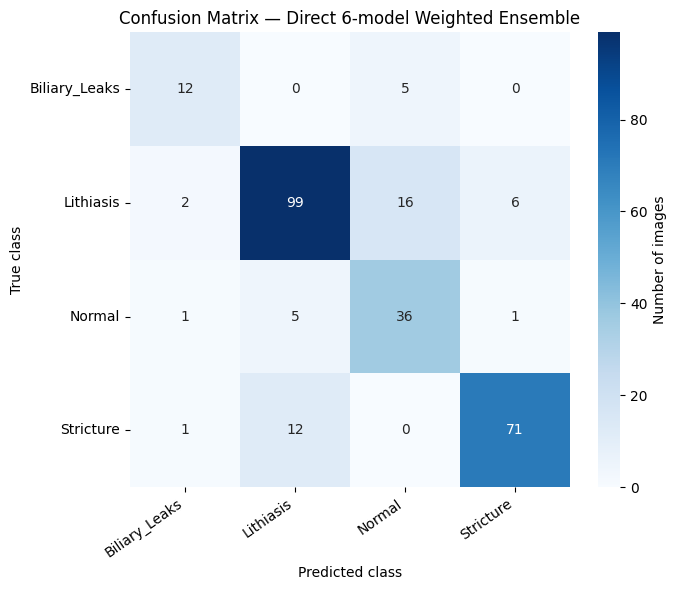

Saved confusion matrix to:
/kaggle/working/direct_6_model_final_outputs/figures/confusion_matrix_test.png


In [16]:
# Final confusion matrix figure

from IPython.display import Image as IPyImage, display
import seaborn as sns

OUTPUT_DIR = Path("/kaggle/working/direct_6_model_final_outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

final_cm = confusion_matrix(
    y_test_multiclass,
    final_selected_test_preds,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={"label": "Number of images"}
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix — Direct 6-model Weighted Ensemble")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

CONFUSION_MATRIX_PATH = FIGURES_DIR / "confusion_matrix_test.png"
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:")
print(CONFUSION_MATRIX_PATH)


## 13. Grad-CAM and Occlusion Sensitivity

This section generates 5 interpretability examples:
- 4 correct predictions, preferably one per class;
- 1 incorrect prediction.


Selected interpretability cases:


,idx,filename,true_class,pred_class,correct,final_confidence,explained_model,explained_model_contribution
0,8,1391_1391_image17609.png,Biliary_Leaks,Biliary_Leaks,True,0.843568,efficientnet_b7,0.371381
1,38,172_172_image1681.png,Lithiasis,Lithiasis,True,0.986595,efficientnet_b7,0.371369
2,154,1550_1550_image18921_section_2.png,Normal,Normal,True,0.866737,efficientnet_b7,0.364881
3,233,727_727_image8480.png,Stricture,Stricture,True,0.945875,efficientnet_b7,0.359880
4,113,714_714_image8333.png,Lithiasis,Normal,False,0.960041,efficientnet_b7,0.369862


Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
EfficientNet-B7: selected Grad-CAM layer features.8.0, output shape (1, 2560, 16, 16)


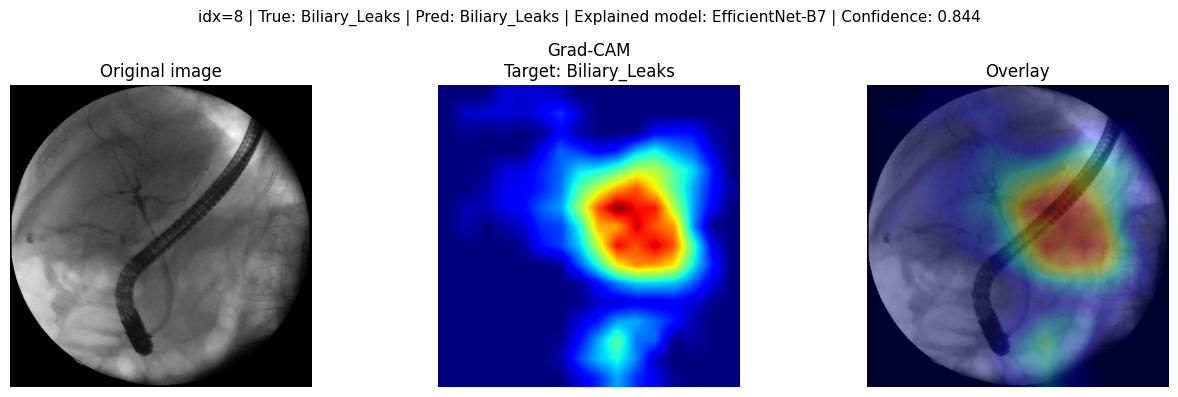

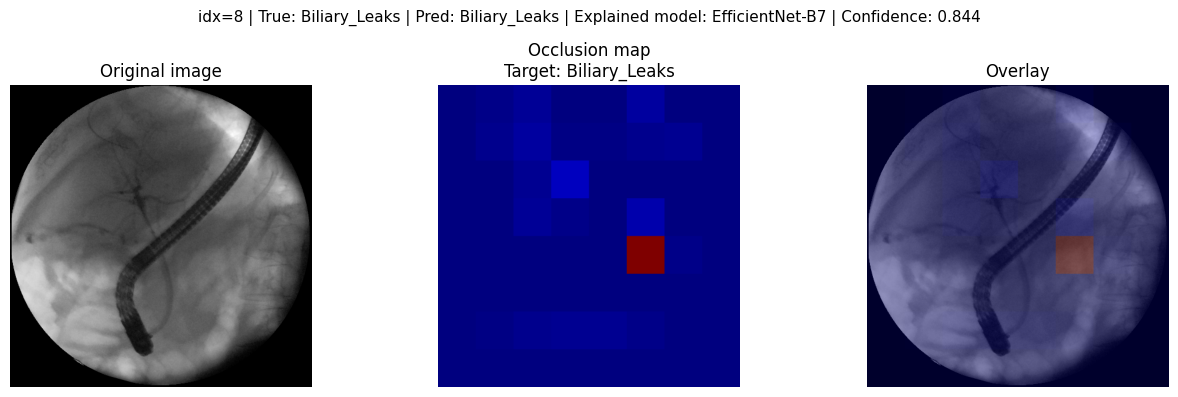

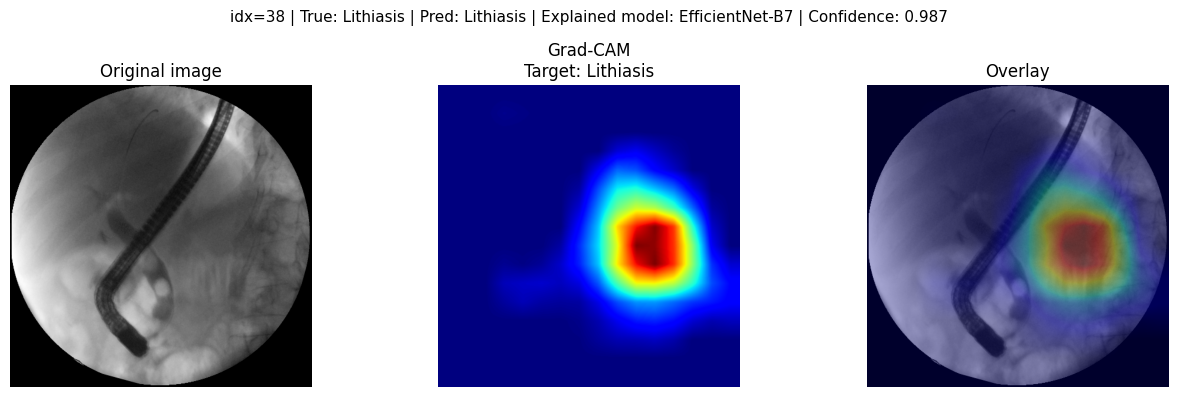

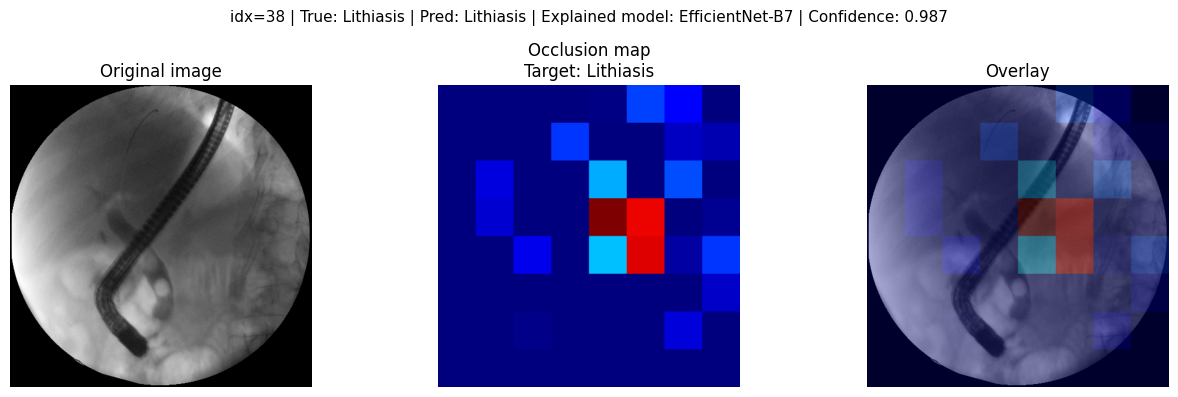

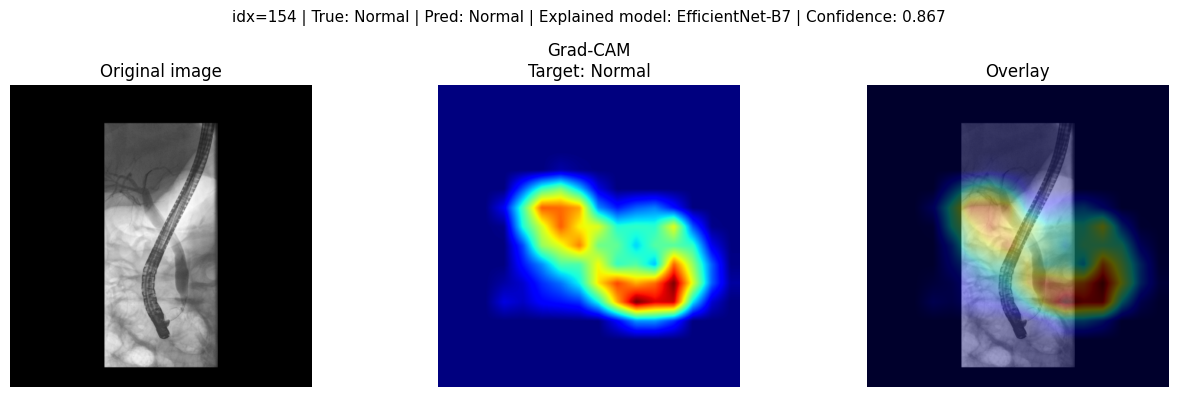

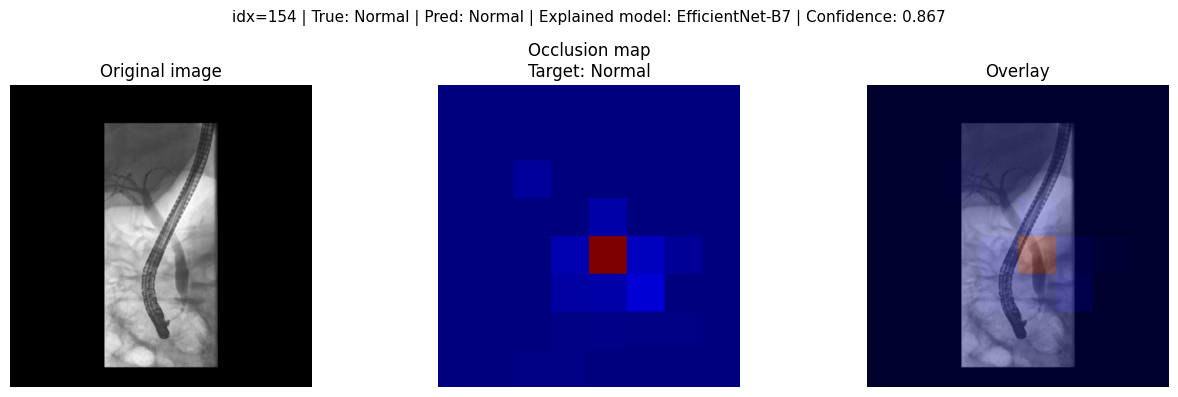

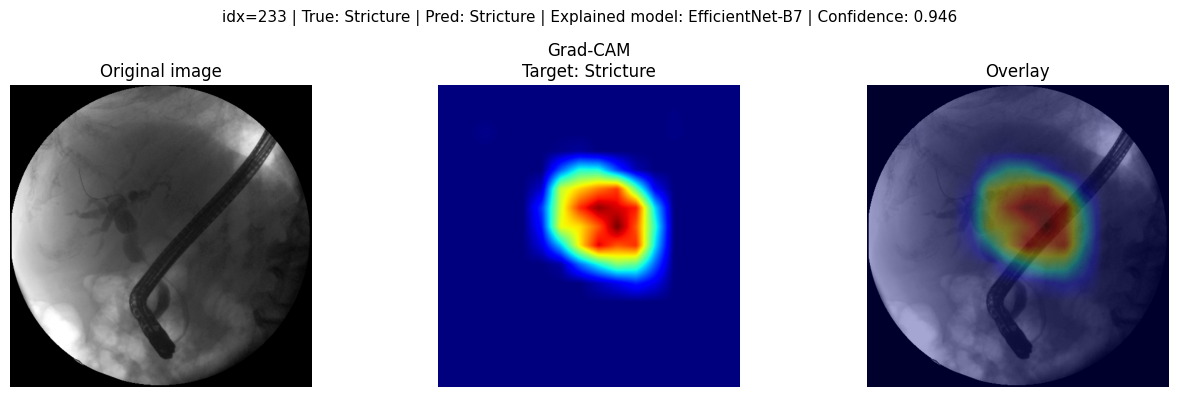

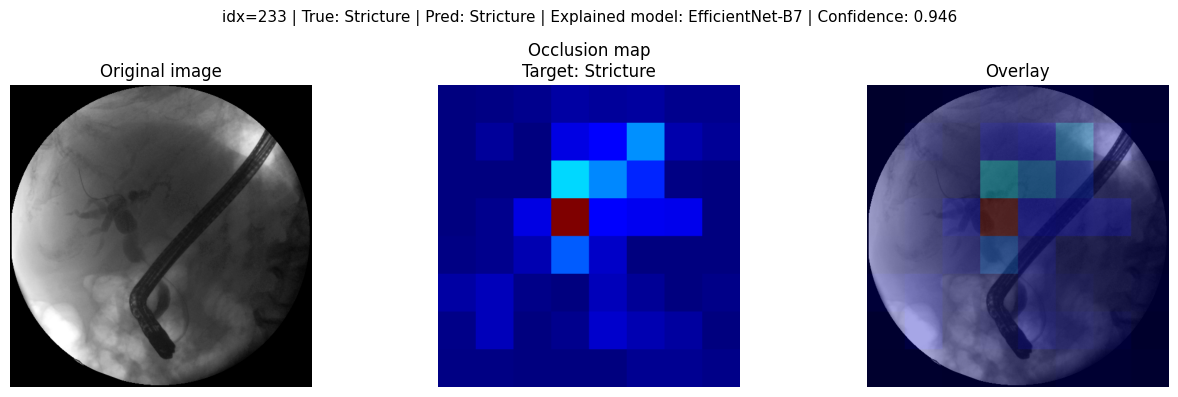

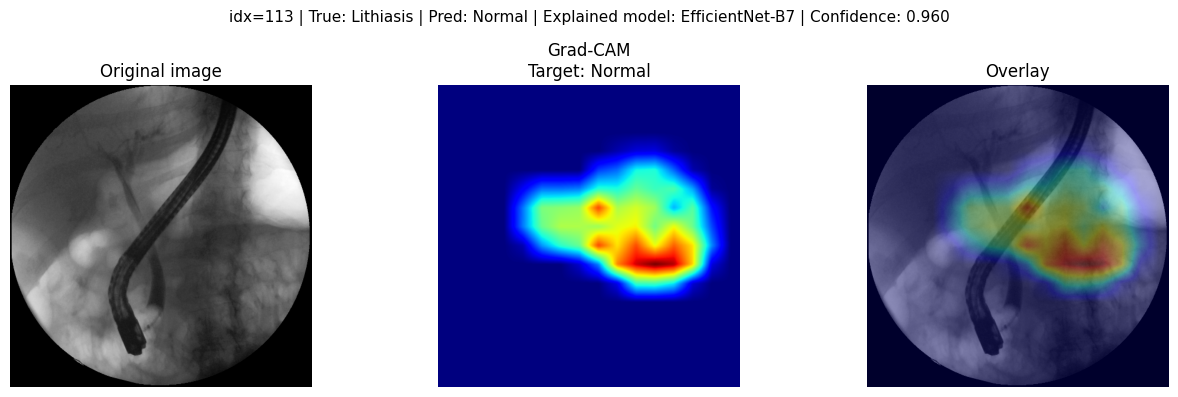

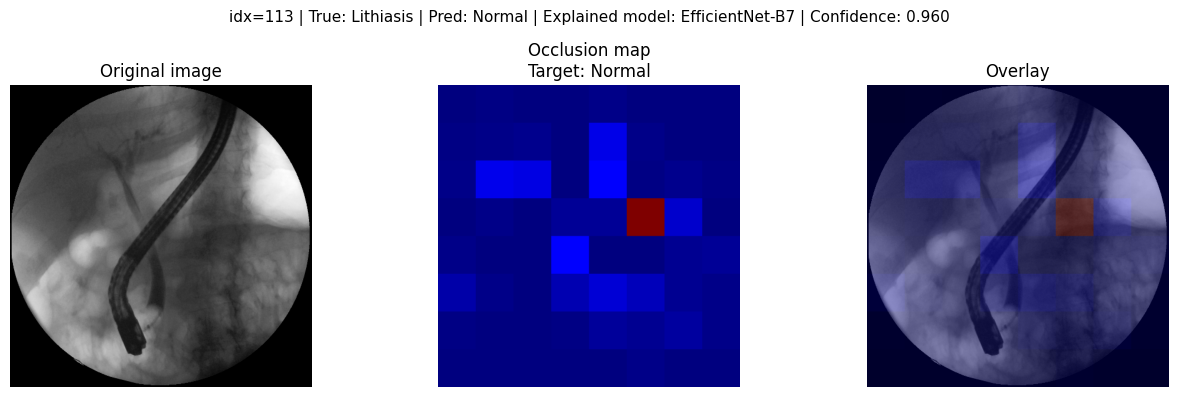

Interpretability outputs:


,idx,filename,true_class,pred_class,correct,final_confidence,explained_model,explained_model_display,target_layer,gradcam_path,occlusion_path
0,8,1391_1391_image17609.png,Biliary_Leaks,Biliary_Leaks,True,0.843568,efficientnet_b7,EfficientNet-B7,features.8.0,/kaggle/working/direct_6_model_final_outputs/i...,/kaggle/working/direct_6_model_final_outputs/i...
1,38,172_172_image1681.png,Lithiasis,Lithiasis,True,0.986595,efficientnet_b7,EfficientNet-B7,features.8.0,/kaggle/working/direct_6_model_final_outputs/i...,/kaggle/working/direct_6_model_final_outputs/i...
2,154,1550_1550_image18921_section_2.png,Normal,Normal,True,0.866737,efficientnet_b7,EfficientNet-B7,features.8.0,/kaggle/working/direct_6_model_final_outputs/i...,/kaggle/working/direct_6_model_final_outputs/i...
3,233,727_727_image8480.png,Stricture,Stricture,True,0.945875,efficientnet_b7,EfficientNet-B7,features.8.0,/kaggle/working/direct_6_model_final_outputs/i...,/kaggle/working/direct_6_model_final_outputs/i...
4,113,714_714_image8333.png,Lithiasis,Normal,False,0.960041,efficientnet_b7,EfficientNet-B7,features.8.0,/kaggle/working/direct_6_model_final_outputs/i...,/kaggle/working/direct_6_model_final_outputs/i...


In [17]:
# Grad-CAM and Occlusion Sensitivity for selected test examples

from PIL import Image
from scipy.ndimage import gaussian_filter
import torch.nn.functional as F
import math
import re

INTERPRETABILITY_DIR = OUTPUT_DIR / "interpretability"
GRADCAM_DIR = INTERPRETABILITY_DIR / "gradcam"
OCCLUSION_DIR = INTERPRETABILITY_DIR / "occlusion"
COMBINED_DIR = INTERPRETABILITY_DIR / "combined"
for d in [INTERPRETABILITY_DIR, GRADCAM_DIR, OCCLUSION_DIR, COMBINED_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# Build case table and select 5 cases

def build_final_case_table():
    rows = []

    for idx, path in enumerate(binary_test_files):
        true_idx = int(y_test_multiclass[idx])
        pred_idx = int(final_selected_test_preds[idx])
        probs = final_selected_test_probs[idx]

        contribution_scores = {
            name: float(BEST_DIRECT_WEIGHTS[i] * test_prob_dict[name][idx, pred_idx])
            for i, name in enumerate(MODEL_ORDER)
        }

        explained_model = max(contribution_scores, key=contribution_scores.get)

        rows.append({
            "idx": idx,
            "path": str(path),
            "filename": Path(path).name,
            "true_idx": true_idx,
            "pred_idx": pred_idx,
            "true_class": CLASS_NAMES[true_idx],
            "pred_class": CLASS_NAMES[pred_idx],
            "correct": bool(true_idx == pred_idx),
            "final_confidence": float(np.max(probs)),
            "true_class_probability": float(probs[true_idx]),
            "predicted_class_probability": float(probs[pred_idx]),
            "explained_model": explained_model,
            "explained_model_contribution": contribution_scores[explained_model],
            **{f"contribution_{name}": score for name, score in contribution_scores.items()},
        })

    return pd.DataFrame(rows)


case_table = build_final_case_table()
case_table.to_csv(INTERPRETABILITY_DIR / "all_test_cases_with_explained_model.csv", index=False)

selected_rows = []

for cls in CLASS_NAMES:
    cls_df = case_table[
        (case_table["correct"]) &
        (case_table["true_class"] == cls)
    ].sort_values(by="final_confidence", ascending=False)

    if len(cls_df) > 0:
        selected_rows.append(cls_df.iloc[0])

error_df = case_table[
    ~case_table["correct"]
].sort_values(by="final_confidence", ascending=False)

if len(error_df) > 0:
    selected_rows.append(error_df.iloc[0])

selected_cases_df = pd.DataFrame(selected_rows).drop_duplicates(subset=["idx"]).head(5).reset_index(drop=True)
selected_cases_df.to_csv(INTERPRETABILITY_DIR / "selected_interpretability_cases.csv", index=False)

print("Selected interpretability cases:")
display(selected_cases_df[[
    "idx", "filename", "true_class", "pred_class", "correct",
    "final_confidence", "explained_model", "explained_model_contribution"
]])


# Component model loading

def load_component_model_for_explainability(model_name):


    if model_name == "efficientnet_b7":
        return create_ensemble_model("efficientnet"), eval_transforms, "EfficientNet-B7"

    if model_name == "densenet121":
        return create_ensemble_model("sandra_densenet"), eval_transforms, "DenseNet121"

    if model_name == "mobilenet_v2":
        return create_ensemble_model("mobilenet"), eval_transforms, "MobileNetV2"

    if model_name == "resnet50":
        return create_ensemble_model("resnet"), eval_transforms, "ResNet50"

    if model_name == "convnext_tiny_vae":
        return create_convnext_tiny_vae_model(strict=True), eval_transforms, "ConvNeXt-Tiny VAE"

    if model_name == "efficientnet_b0_vae":
        return create_efficientnet_b0_vae_model(), b0_eval_transforms, "EfficientNet-B0 VAE"

    raise ValueError(f"Unknown component model: {model_name}")


def load_tensor_for_model(path, transform):
    tensor = transform(str(path))
    return tensor.float()


def clear_all_hooks(model):
    # Best-effort cleanup for old hooks.
    for module in model.modules():
        if hasattr(module, "_forward_hooks"):
            module._forward_hooks.clear()
        if hasattr(module, "_backward_hooks"):
            module._backward_hooks.clear()
        if hasattr(module, "_forward_pre_hooks"):
            module._forward_pre_hooks.clear()


def find_used_last_conv_layer(model, sample_tensor, model_name="model"):
    model.eval()
    conv_outputs = []
    hooks = []

    def make_hook(name):
        def hook(module, inputs, output):
            if isinstance(output, torch.Tensor) and output.ndim == 4:
                _, _, h, w = output.shape
                if h > 1 and w > 1:
                    conv_outputs.append((name, module, tuple(output.shape)))
        return hook

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            hooks.append(module.register_forward_hook(make_hook(name)))

    with torch.no_grad():
        _ = model(sample_tensor.unsqueeze(0).to(device))

    for hook in hooks:
        hook.remove()

    if len(conv_outputs) == 0:
        raise RuntimeError(f"No usable Conv2d layer found for {model_name}.")

    layer_name, layer, shape = conv_outputs[-1]
    print(f"{model_name}: selected Grad-CAM layer {layer_name}, output shape {shape}")
    return layer, layer_name


class StableGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = self.target_layer.register_forward_hook(self._save_activations)
        self.backward_hook = self.target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inputs, output):
        self.activations = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def __call__(self, input_tensor, target_class):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        x = input_tensor.unsqueeze(0).to(device)
        x.requires_grad_(True)

        logits = self.model(x)
        score = logits[0, int(target_class)]

        score.backward()

        activations = self.activations.detach()
        gradients = self.gradients.detach()

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam[0, 0].detach().cpu().numpy()
        cam = gaussian_filter(cam, sigma=1.2)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam


@torch.no_grad()
def get_target_probability(model, input_tensor, target_class):
    model.eval()
    logits = model(input_tensor.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1)
    return float(probs[0, int(target_class)].detach().cpu())


@torch.no_grad()
def compute_occlusion_map(model, input_tensor, target_class, patch_size=None, stride=None):

    model.eval()

    c, h, w = input_tensor.shape

    if patch_size is None:
        patch_size = 32 if max(h, w) <= 256 else 64

    if stride is None:
        stride = patch_size

    baseline_prob = get_target_probability(model, input_tensor, target_class)

    occ_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    fill_value = float(input_tensor.mean().detach().cpu())

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)

            occluded = input_tensor.clone()
            occluded[:, y:y2, x:x2] = fill_value

            prob = get_target_probability(model, occluded, target_class)
            drop = baseline_prob - prob

            occ_map[y:y2, x:x2] += drop
            count_map[y:y2, x:x2] += 1.0

    occ_map = occ_map / np.maximum(count_map, 1.0)
    occ_map = np.maximum(occ_map, 0.0)

    if occ_map.max() > 0:
        occ_map = occ_map / (occ_map.max() + 1e-8)

    return occ_map


def make_safe_name(text):
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(text)).strip("_")


def save_gradcam_figure(row, raw_img, cam, display_model_name):
    idx = int(row["idx"])
    true_class = row["true_class"]
    pred_class = row["pred_class"]
    target_class = pred_class
    status = "correct" if bool(row["correct"]) else "incorrect"

    filename = f"{idx:03d}_{status}_{make_safe_name(true_class)}_pred_{make_safe_name(pred_class)}_gradcam.png"
    out_path = GRADCAM_DIR / filename

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(raw_img, cmap="gray")
    axes[0].axis("off")
    axes[0].set_title("Original image")

    axes[1].imshow(cam, cmap="jet", interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(f"Grad-CAM\nTarget: {target_class}")

    axes[2].imshow(raw_img, cmap="gray")
    axes[2].imshow(cam, cmap="jet", alpha=0.35, interpolation="bilinear")
    axes[2].axis("off")
    axes[2].set_title("Overlay")

    fig.suptitle(
        f"idx={idx} | True: {true_class} | Pred: {pred_class} | "
        f"Explained model: {display_model_name} | Confidence: {row['final_confidence']:.3f}",
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return out_path


def save_occlusion_figure(row, raw_img, occ_map, display_model_name):
    idx = int(row["idx"])
    true_class = row["true_class"]
    pred_class = row["pred_class"]
    target_class = pred_class
    status = "correct" if bool(row["correct"]) else "incorrect"

    filename = f"{idx:03d}_{status}_{make_safe_name(true_class)}_pred_{make_safe_name(pred_class)}_occlusion.png"
    out_path = OCCLUSION_DIR / filename

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(raw_img, cmap="gray")
    axes[0].axis("off")
    axes[0].set_title("Original image")

    axes[1].imshow(occ_map, cmap="jet", interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(f"Occlusion map\nTarget: {target_class}")

    axes[2].imshow(raw_img, cmap="gray")
    axes[2].imshow(occ_map, cmap="jet", alpha=0.35, interpolation="bilinear")
    axes[2].axis("off")
    axes[2].set_title("Overlay")

    fig.suptitle(
        f"idx={idx} | True: {true_class} | Pred: {pred_class} | "
        f"Explained model: {display_model_name} | Confidence: {row['final_confidence']:.3f}",
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return out_path


# Generate Grad-CAM and Occlusion for the selected 5 cases

interpretability_rows = []
model_cache = {}

for _, row in selected_cases_df.iterrows():
    model_key = row["explained_model"]

    if model_key not in model_cache:
        model, transform, display_model_name = load_component_model_for_explainability(model_key)
        clear_all_hooks(model)

        # Use this row's image to choose a valid Grad-CAM layer.
        sample_tensor = load_tensor_for_model(row["path"], transform)
        target_layer, target_layer_name = find_used_last_conv_layer(
            model,
            sample_tensor,
            model_name=display_model_name
        )

        gradcam_object = StableGradCAM(model, target_layer)

        model_cache[model_key] = {
            "model": model,
            "transform": transform,
            "display_name": display_model_name,
            "gradcam": gradcam_object,
            "target_layer_name": target_layer_name,
        }

    cache = model_cache[model_key]
    model = cache["model"]
    transform = cache["transform"]
    display_model_name = cache["display_name"]
    gradcam_object = cache["gradcam"]

    input_tensor = load_tensor_for_model(row["path"], transform)
    raw_img = Image.open(row["path"]).convert("L")

    target_class = int(row["pred_idx"])

    cam = gradcam_object(input_tensor, target_class=target_class)
    occ_map = compute_occlusion_map(model, input_tensor, target_class=target_class)

    gradcam_path = save_gradcam_figure(row, raw_img, cam, display_model_name)
    occlusion_path = save_occlusion_figure(row, raw_img, occ_map, display_model_name)

    interpretability_rows.append({
        "idx": int(row["idx"]),
        "filename": row["filename"],
        "true_class": row["true_class"],
        "pred_class": row["pred_class"],
        "correct": bool(row["correct"]),
        "final_confidence": float(row["final_confidence"]),
        "explained_model": model_key,
        "explained_model_display": display_model_name,
        "target_layer": cache["target_layer_name"],
        "gradcam_path": str(gradcam_path),
        "occlusion_path": str(occlusion_path),
    })

interpretability_summary_df = pd.DataFrame(interpretability_rows)
interpretability_summary_df.to_csv(INTERPRETABILITY_DIR / "interpretability_summary.csv", index=False)

print("Interpretability outputs:")
display(interpretability_summary_df)

# Cleanup hooks
for cache in model_cache.values():
    cache["gradcam"].remove_hooks()


## 14. Save metrics and package all final artifacts

In [18]:
# Save metrics and package final artifacts into one ZIP

import json
import shutil
import os
import subprocess
from IPython.display import FileLink, display

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR = OUTPUT_DIR / "metrics"
CONFIG_DIR = OUTPUT_DIR / "config"
PROBS_DIR = OUTPUT_DIR / "probabilities"
for d in [METRICS_DIR, CONFIG_DIR, PROBS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Save search results and final metrics

weight_search_df.to_csv(OUTPUT_DIR / "direct_weight_search_results.csv", index=False)
comparison_df.to_csv(OUTPUT_DIR / "direct_weight_comparison.csv", index=False)

selected_weights_df = pd.DataFrame([{
    "model": name,
    "weight": float(weight),
} for name, weight in zip(MODEL_ORDER, BEST_DIRECT_WEIGHTS)])

selected_weights_df.to_csv(CONFIG_DIR / "selected_direct_weights.csv", index=False)

final_report_dict = classification_report(
    y_test_multiclass,
    final_selected_test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)

pd.DataFrame(final_report_dict).transpose().to_csv(METRICS_DIR / "classification_report_test.csv")

final_cm = confusion_matrix(y_test_multiclass, final_selected_test_preds, labels=list(range(NUM_CLASSES)))
pd.DataFrame(
    final_cm,
    index=[f"true_{c}" for c in CLASS_NAMES],
    columns=[f"pred_{c}" for c in CLASS_NAMES],
).to_csv(METRICS_DIR / "confusion_matrix_test.csv")

np.save(PROBS_DIR / "final_val_probs.npy", final_selected_val_probs)
np.save(PROBS_DIR / "final_test_probs.npy", final_selected_test_probs)
np.save(PROBS_DIR / "final_val_preds.npy", final_selected_val_preds)
np.save(PROBS_DIR / "final_test_preds.npy", final_selected_test_preds)
np.save(PROBS_DIR / "y_val_multiclass.npy", y_val_multiclass)
np.save(PROBS_DIR / "y_test_multiclass.npy", y_test_multiclass)

summary = {
    "model_name": FINAL_MODEL_NAME,
    "class_names": CLASS_NAMES,
    "model_order": MODEL_ORDER,
    "val_macro_f1": float(final_selected_val_eval["macro_f1"]),
    "test_macro_f1": float(final_selected_test_eval["macro_f1"]),
    "val_accuracy": float(final_selected_val_eval["accuracy"]),
    "test_accuracy": float(final_selected_test_eval["accuracy"]),
    "weights": {name: float(weight) for name, weight in zip(MODEL_ORDER, BEST_DIRECT_WEIGHTS)},
    "confusion_matrix": final_cm.tolist(),
}

with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Save final ensemble config as JSON and PTH

checkpoint_paths = {
    "efficientnet_b7": str(SANDRA_MODELS["efficientnet"]),
    "densenet121": str(SANDRA_MODELS["sandra_densenet"]),
    "mobilenet_v2": str(SANDRA_MODELS["mobilenet"]),
    "resnet50": str(SANDRA_MODELS["resnet"]),
    "convnext_tiny_vae": str(CONVNEXT_CKPT_PATH),
    "efficientnet_b0_vae": str(EFFICIENTNET_B0_CKPT_PATH),
}

final_ensemble_config = {
    "model_name": FINAL_MODEL_NAME,
    "description": "Direct 6-model weighted ensemble. The final model is reconstructed from individual checkpoints plus these weights.",
    "class_names": CLASS_NAMES,
    "model_order": MODEL_ORDER,
    "weights": {name: float(weight) for name, weight in zip(MODEL_ORDER, BEST_DIRECT_WEIGHTS)},
    "checkpoint_paths_original": checkpoint_paths,
    "transforms": {
        "efficientnet_b7": "eval_transforms: LoadImage -> EnsureChannelFirst -> Resize((512,512)) -> NormalizeIntensity -> repeat_if_needed -> ToTensor",
        "densenet121": "eval_transforms: LoadImage -> EnsureChannelFirst -> Resize((512,512)) -> NormalizeIntensity -> repeat_if_needed -> ToTensor",
        "mobilenet_v2": "eval_transforms: LoadImage -> EnsureChannelFirst -> Resize((512,512)) -> NormalizeIntensity -> repeat_if_needed -> ToTensor",
        "resnet50": "eval_transforms: LoadImage -> EnsureChannelFirst -> Resize((512,512)) -> NormalizeIntensity -> repeat_if_needed -> ToTensor",
        "convnext_tiny_vae": "eval_transforms: LoadImage -> EnsureChannelFirst -> Resize((512,512)) -> NormalizeIntensity -> repeat_if_needed -> ToTensor",
        "efficientnet_b0_vae": "b0_eval_transforms: LoadImage -> EnsureChannelFirst -> Resize((224,224)) -> NormalizeIntensity -> repeat_if_needed -> ToTensor",
    },
    "final_results": {
        "val_macro_f1": float(final_selected_val_eval["macro_f1"]),
        "test_macro_f1": float(final_selected_test_eval["macro_f1"]),
        "val_accuracy": float(final_selected_val_eval["accuracy"]),
        "test_accuracy": float(final_selected_test_eval["accuracy"]),
    }
}

with open(CONFIG_DIR / "final_direct_6_model_ensemble_config.json", "w") as f:
    json.dump(final_ensemble_config, f, indent=2)

torch.save(
    final_ensemble_config,
    CONFIG_DIR / "final_direct_6_model_ensemble_config.pth"
)

# Create final package directory

PACKAGE_DIR = Path("/kaggle/working/final_direct_6_model_ensemble_package")

if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)

PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

# Copy all outputs produced above.
shutil.copytree(OUTPUT_DIR, PACKAGE_DIR / "outputs")

# Copy all model checkpoints used by the final ensemble

CHECKPOINT_DIR = PACKAGE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_copy_map = {
    "efficientnet_b7.pth": SANDRA_MODELS["efficientnet"],
    "densenet121.pth": SANDRA_MODELS["sandra_densenet"],
    "mobilenet_v2.pth": SANDRA_MODELS["mobilenet"],
    "resnet50.pth": SANDRA_MODELS["resnet"],
    "convnext_tiny_vae.pth": CONVNEXT_CKPT_PATH,
    "efficientnet_b0_vae.pth": EFFICIENTNET_B0_CKPT_PATH,
}

copied_checkpoints = {}

for output_name, source_path in checkpoint_copy_map.items():
    source_path = Path(source_path)

    if source_path.exists():
        destination = CHECKPOINT_DIR / output_name
        shutil.copy2(source_path, destination)
        copied_checkpoints[output_name] = {
            "original_path": str(source_path),
            "packaged_path": str(destination.relative_to(PACKAGE_DIR)),
            "size_mb": destination.stat().st_size / (1024 ** 2),
        }
        print(f"Copied checkpoint: {output_name}")
    else:
        print(f"Missing checkpoint, not copied: {source_path}")

with open(PACKAGE_DIR / "checkpoint_manifest.json", "w") as f:
    json.dump(copied_checkpoints, f, indent=2)

# Try to copy the current notebook

NOTEBOOK_DIR = PACKAGE_DIR / "notebook"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

notebook_candidates = [
    Path("/kaggle/working/__notebook__.ipynb"),
    Path("/kaggle/working/notebook.ipynb"),
]

notebook_candidates.extend(Path("/kaggle/working").glob("*.ipynb"))

copied_notebook = False

for nb_path in notebook_candidates:
    if nb_path.exists() and nb_path.is_file():
        shutil.copy2(nb_path, NOTEBOOK_DIR / nb_path.name)
        print("Copied notebook:", nb_path)
        copied_notebook = True

if not copied_notebook:
    note = (
        "No current notebook file was found automatically in /kaggle/working.\n"
        "In Kaggle, use Save Version / Download Notebook to preserve the executed notebook.\n"
        "All code-dependent configuration, checkpoints, metrics and outputs are included in this package.\n"
    )
    with open(NOTEBOOK_DIR / "NOTEBOOK_NOT_AUTOMATICALLY_FOUND.txt", "w") as f:
        f.write(note)
    print(note)

# Save environment snapshot

try:
    reqs = subprocess.check_output(["pip", "freeze"], text=True)
    with open(PACKAGE_DIR / "requirements_snapshot.txt", "w") as f:
        f.write(reqs)
except Exception as exc:
    with open(PACKAGE_DIR / "requirements_snapshot_error.txt", "w") as f:
        f.write(str(exc))

# README

readme_text = f"""
# Final Direct 6-Model Ensemble Package

This package contains the final ERCP image classification ensemble.

## Final model

The final model is not a single neural network checkpoint. It is a direct weighted ensemble
of six separately trained models. The final probabilities are computed as:

P_final = sum_m w_m * P_m

where P_m is the class-probability vector produced by component model m.

## Models and weights

{selected_weights_df.to_string(index=False)}

## Final results

Validation Macro-F1: {float(final_selected_val_eval["macro_f1"]):.4f}
Validation Accuracy: {float(final_selected_val_eval["accuracy"]):.4f}

Test Macro-F1: {float(final_selected_test_eval["macro_f1"]):.4f}
Test Accuracy: {float(final_selected_test_eval["accuracy"]):.4f}

## Contents

- checkpoints/
  Individual .pth checkpoints for the six component models.
- outputs/config/
  Final ensemble configuration in JSON and .pth format.
- outputs/metrics/
  Classification report and confusion matrix.
- outputs/figures/
  Confusion matrix image.
- outputs/interpretability/
  Grad-CAM and Occlusion Sensitivity images for 5 selected test examples.
- outputs/probabilities/
  Final validation/test probabilities, predictions and labels.
- notebook/
  Current notebook, if Kaggle exposes it in /kaggle/working.
- requirements_snapshot.txt
  Python package snapshot.

## Dataset

The dataset is not included in this package. To reproduce the results, use the same MIQR-CC
train/validation/test split paths used in the notebook.

## Important note

There is no single .pth file representing the whole ensemble. The ensemble is reconstructed from:
1. the six individual checkpoints in checkpoints/;
2. the weights stored in outputs/config/final_direct_6_model_ensemble_config.json;
3. the class order stored in the same config file.
"""

with open(PACKAGE_DIR / "README.txt", "w") as f:
    f.write(readme_text)

# Zip package

zip_base = "/kaggle/working/final_direct_6_model_ensemble_package"
zip_path = Path(zip_base + ".zip")

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir="/kaggle/working",
    base_dir="final_direct_6_model_ensemble_package"
)

print("\nFinal package created:")
print(zip_path)
print("Size MB:", zip_path.stat().st_size / (1024 ** 2))

os.chdir("/kaggle/working")
display(FileLink("final_direct_6_model_ensemble_package.zip"))


Copied checkpoint: efficientnet_b7.pth
Copied checkpoint: densenet121.pth
Copied checkpoint: mobilenet_v2.pth
Copied checkpoint: resnet50.pth
Copied checkpoint: convnext_tiny_vae.pth
Copied checkpoint: efficientnet_b0_vae.pth
No current notebook file was found automatically in /kaggle/working.
In Kaggle, use Save Version / Download Notebook to preserve the executed notebook.
All code-dependent configuration, checkpoints, metrics and outputs are included in this package.


Final package created:
/kaggle/working/final_direct_6_model_ensemble_package.zip
Size MB: 465.4524173736572


/kaggle/working/final_direct_6_model_ensemble_package.zip